In [49]:
def compare_regularisation(X_train, y_train, X_test, y_test, C_values):

    results = []

    for C in C_values:
        print("Testing C =", C)

In [50]:
        lasso = LogisticRegression(
            penalty='l1',
            C=C,
            solver='liblinear',
            max_iter=2000
        )

        lasso.fit(X_train, y_train)

        lasso_acc = accuracy_score(
            y_test,
            lasso.predict(X_test)
        )

In [53]:
        ridge = LogisticRegression(
            penalty='l2',
            C=C,
            solver='liblinear',
            max_iter=5000
        )

        ridge.fit(X_train, y_train)

        ridge_acc = accuracy_score(
            y_test,
            ridge.predict(X_test)
        )

In [55]:
elastic = LogisticRegression(
    penalty='elasticnet',
    C=0.1,
    solver='saga',
    l1_ratio=0.5,
    max_iter=500,
    tol=1e-3,
    random_state=42
)

elastic.fit(X_train, y_train)

elastic_acc = accuracy_score(
    y_test,
    elastic.predict(X_test)
)

print("Elastic Net Accuracy:", elastic_acc)

Elastic Net Accuracy: 0.6747


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [57]:
results_list = []

results_list.append({
    'C': C,
    'Lasso_Accuracy': lasso_acc,
    'Ridge_Accuracy': ridge_acc,
    'ElasticNet_Accuracy': elastic_acc
})

print(results_list)

[{'C': 100, 'Lasso_Accuracy': 0.7969, 'Ridge_Accuracy': 0.7946, 'ElasticNet_Accuracy': 0.6747}]


In [58]:
results_list[0]['Lasso_Nonzero'] = np.sum(lasso.coef_ != 0)
results_list[0]['Ridge_Nonzero'] = np.sum(ridge.coef_ != 0)

print(results_list)

[{'C': 100, 'Lasso_Accuracy': 0.7969, 'Ridge_Accuracy': 0.7946, 'ElasticNet_Accuracy': 0.6747, 'Lasso_Nonzero': np.int64(45), 'Ridge_Nonzero': np.int64(45)}]


In [59]:
skill_result = pd.DataFrame(results_list)

print("Regularisation Comparison:")
print(skill_result)

Regularisation Comparison:
     C  Lasso_Accuracy  Ridge_Accuracy  ElasticNet_Accuracy  Lasso_Nonzero  \
0  100          0.7969          0.7946               0.6747             45   

   Ridge_Nonzero  
0             45  


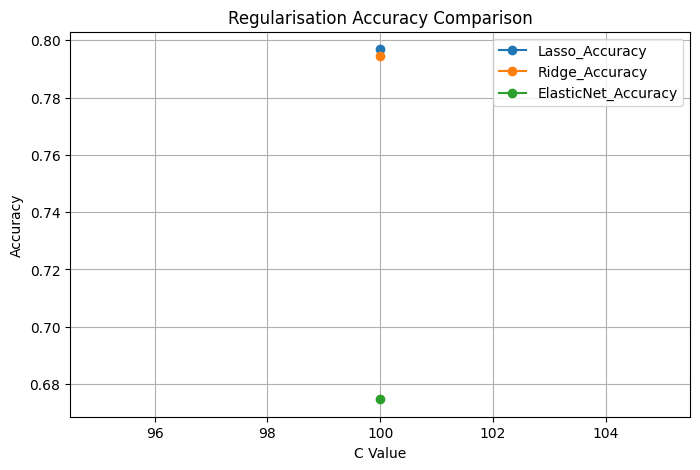

In [60]:
skill_result.plot(
    x='C',
    y=['Lasso_Accuracy', 'Ridge_Accuracy', 'ElasticNet_Accuracy'],
    marker='o',
    figsize=(8, 5)
)

plt.title("Regularisation Accuracy Comparison")
plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

Lasso non-zero coefficients: 45
Ridge non-zero coefficients: 45


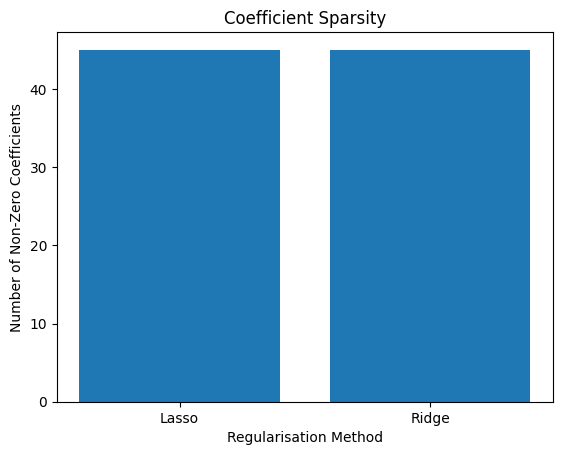

In [61]:
print("Lasso non-zero coefficients:", skill_result['Lasso_Nonzero'].iloc[0])
print("Ridge non-zero coefficients:", skill_result['Ridge_Nonzero'].iloc[0])

plt.bar(
    ['Lasso', 'Ridge'],
    [
        skill_result['Lasso_Nonzero'].iloc[0],
        skill_result['Ridge_Nonzero'].iloc[0]
    ]
)

plt.title("Coefficient Sparsity")
plt.xlabel("Regularisation Method")
plt.ylabel("Number of Non-Zero Coefficients")
plt.show()

In [62]:
best_method = skill_result[
    ['Lasso_Accuracy', 'Ridge_Accuracy', 'ElasticNet_Accuracy']
].iloc[0].idxmax()

print("Best Regularisation Method:", best_method)
print("\nFinal Comparison:")
print(skill_result)

Best Regularisation Method: Lasso_Accuracy

Final Comparison:
     C  Lasso_Accuracy  Ridge_Accuracy  ElasticNet_Accuracy  Lasso_Nonzero  \
0  100          0.7969          0.7946               0.6747             45   

   Ridge_Nonzero  
0             45  
